In [2]:
!pip install --quiet numpy pandas matplotlib
print("Installation done or Libraries already existed")

Installation done or Libraries already existed


In [4]:
#importing libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#loading the data 
Data_path = r"C:\Users\lovey\OneDrive\Desktop\DataSets\air_quality_health_dataset.csv"

df = pd.read_csv(Data_path)
print("Data successfully loaded")
print("Shape",df.shape)
df.head(10)

Data successfully loaded
Shape (3000, 26)


,date,region,AQI,PM2.5,PM10,NO2,SO2,CO,O3,temperature,...,school_closures,public_transport_usage,mask_usage_rate,lockdown_status,industrial_activity,vehicle_count,construction_activity,respiratory_admissions,population_density,green_cover_percentage
0,01-01-2020,East,109.934283,31.382887,57.718373,47.654022,25.874070,0.956973,32.574682,37.555663,...,0,43.103376,75.706162,0,66.098466,9757,63.001573,11,1957.637287,42.348419
1,02-01-2020,Central,97.234714,47.094225,67.381383,50.734127,10.605095,0.990203,23.749138,24.900342,...,0,30.606591,69.652802,0,107.686174,9157,6.417798,13,2962.769470,27.712735
2,03-01-2020,East,112.953771,53.795917,61.158796,44.986899,18.361025,1.019288,35.530851,23.437165,...,0,13.037424,82.561183,1,77.445192,2058,66.001849,3,6912.007043,41.031516
3,04-01-2020,West,130.460597,88.315315,69.040084,20.575023,19.791700,1.284058,25.277106,22.388200,...,0,8.974779,73.642836,0,51.864000,8726,79.580923,6,9227.543628,40.543537
4,05-01-2020,South,95.316933,68.348297,75.716994,38.445776,20.079543,0.775835,35.996440,26.881835,...,1,96.022689,68.688106,0,148.714488,9720,6.301105,8,1277.810175,5.648920
5,06-01-2020,South,95.317261,39.967776,96.743090,28.442924,20.902480,0.746096,27.807108,26.932913,...,0,99.515344,67.393778,0,121.617654,4069,84.842058,9,6428.622693,47.149910
6,07-01-2020,West,131.584256,67.290544,73.576819,37.973942,23.052199,1.370986,16.231623,29.753139,...,0,89.792538,57.895350,0,123.546323,2500,12.335902,8,3831.189452,19.034779
7,08-01-2020,West,115.348695,36.790440,48.287486,49.800042,19.822963,0.861207,22.140670,20.369689,...,0,45.863143,76.470659,0,116.295865,8068,17.583370,13,3284.793439,41.342931
8,09-01-2020,North,90.610512,76.240366,102.801357,43.051508,18.159709,0.621089,26.556682,23.437526,...,0,80.791576,75.992329,0,64.373847,4705,83.640354,8,1882.424687,63.199856
9,10-01-2020,East,110.851201,52.933130,63.258197,51.480909,17.962053,0.854461,40.945512,35.152729,...,0,83.428220,79.538477,0,70.669442,8036,12.470203,11,8892.778335,17.498740


In [6]:
# Checking for clean data 
print("Column names",df.columns)
print("\n Data type",df.dtypes)
print("\n Missing Columns",df.isna().sum())

Column names Index(['date', 'region', 'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
       'temperature', 'humidity', 'wind_speed', 'precipitation',
       'hospital_visits', 'emergency_visits', 'mobility_index',
       'school_closures', 'public_transport_usage', 'mask_usage_rate',
       'lockdown_status', 'industrial_activity', 'vehicle_count',
       'construction_activity', 'respiratory_admissions', 'population_density',
       'green_cover_percentage'],
      dtype='object')

 Data type date                       object
region                     object
AQI                       float64
PM2.5                     float64
PM10                      float64
NO2                       float64
SO2                       float64
CO                        float64
O3                        float64
temperature               float64
humidity                  float64
wind_speed                float64
precipitation             float64
hospital_visits             int64
emergency_visits      

In [43]:
# Selecting features and target values

y_raw = df["AQI"].values.reshape(-1,1) # Updated step

y_mean = y_raw.mean()       # Updated step
y_std = y_raw.std()         # Updated step

y = (y_raw - y_mean)/y_std   # Updated step

# Numeric features 
numeric_features = [
    'PM2.5','PM10','NO2','SO2','CO','O3',
    'temperature','humidity','wind_speed','precipitation',
    'hospital_visits','emergency_visits','mobility_index',
    'school_closures','public_transport_usage','mask_usage_rate',
    'lockdown_status','industrial_activity','vehicle_count',
    'construction_activity','respiratory_admissions',
    'population_density','green_cover_percentage'
]

X_num = df[numeric_features].values

# Categorical features
X_cat = df["region"].values

print("target values, numeric features and categorical features are set")

target values, numeric features and categorical features are set


In [44]:
# Manual One Hot encoding

X_region = pd.get_dummies(X_cat, drop_first=True).values

print("Numeric Shape:", X_num.shape)
print("Region Shape:", X_region.shape)


Numeric Shape: (3000, 23)
Region Shape: (3000, 4)


In [45]:
# Combining features 

X = np.hstack([X_num,X_region])
print("final feature matrix shape : ",X.shape)

final feature matrix shape :  (3000, 27)


In [46]:
# Manual feature scaling(Standardization)

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

#prevent devide by zero
X_std[X_std == 0] = 1

X_scaled = (X - X_mean)/X_std

# Same job as StandardScaler but fully manual.
print("Standardization is done")

Standardization is done


In [47]:
# Add Bias(Intercept Column)

m = X_scaled.shape[0]

X_design = np.c_[np.ones((m,1)),X_scaled]
print("Design matrix shape",X_design.shape)

#This creates x₀ = 1 for θ₀ (bias).

Design matrix shape (3000, 28)


In [48]:
# Manual test-train split

np.random.seed(42)
indices = np.random.permutation(m)

train_size = int(0.8*m)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X_design[train_idx]
y_train = y[train_idx]

X_test = X_design[test_idx]
y_test = y[test_idx]

print("Train Shape",X_train.shape,y_train.shape)
print("\n Test Shape",X_test.shape,y_test.shape)

Train Shape (2400, 28) (2400, 1)

 Test Shape (600, 28) (600, 1)


In [53]:
# Hypothesis function
def predict(X, theta):
    return X @ theta

# Mean Squared Error Loss
def compute_loss(X, y, theta):
    m = len(y)
    return (1/(2*m)) * np.sum((predict(X, theta) - y)**2)

# Stochastic Gradient Descent WITH GRADIENT CLIPPING
def stochastic_gradient_descent(X, y, lr=0.001, epochs=100, clip_value=0.5):
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)

        for i in indices:
            xi = X[i].reshape(1, -1)
            yi = y[i]

            gradient = xi.T @ (xi @ theta - yi)

            # GRADIENT CLIPPING (this prevents explosion)
            gradient = np.clip(gradient, -clip_value, clip_value)

            theta = theta - lr * gradient

        loss = compute_loss(X, y, theta)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.6f}")

    return theta, loss_history


In [54]:
# Train the model

theta_sgd, loss_history = stochastic_gradient_descent(
    X_train,y_train,
    lr = 0.001,
    epochs = 150,
    clip_value = 0.5
)


Epoch 0, Loss: 0.493973
Epoch 10, Loss: 0.494577
Epoch 20, Loss: 0.495290
Epoch 30, Loss: 0.494507
Epoch 40, Loss: 0.494805
Epoch 50, Loss: 0.494551
Epoch 60, Loss: 0.494838
Epoch 70, Loss: 0.495333
Epoch 80, Loss: 0.495137
Epoch 90, Loss: 0.495112
Epoch 100, Loss: 0.494424
Epoch 110, Loss: 0.494660
Epoch 120, Loss: 0.495189
Epoch 130, Loss: 0.494689
Epoch 140, Loss: 0.494482


In [55]:
# Predicting on test data 
y_pred_scaled = predict(X_test,theta_sgd)

In [56]:
# Unscaling predictions back to real AQI

y_pred_real = y_pred_scaled * y_std + y_mean
y_test_real = y_test * y_std + y_mean

In [59]:
# Final evaluation metrics(Real AQI)

rmse = np.sqrt(np.mean((y_test_real - y_pred_real)**2))
mae = np.mean(np.abs(y_test - y_pred_real))

ss_total = np.sum((y_test_real - y_test_real.mean())**2)
ss_residual = np.sum((y_test_real - y_pred_real)**2)
r2 = 1-ss_residual/ss_total

print("SCRATCH SGD LINEAR REGRESSION RESULTS (REAL AQI)")
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

SCRATCH SGD LINEAR REGRESSION RESULTS (REAL AQI)
RMSE: 19.99866843867288
MAE : 100.54423157510422
R²  : -0.003533961571826172


In [61]:
# ✅ FINAL CLEAN METRICS (FORCE RECALCULATION)

# Ensure both are REAL AQI values
print("Sanity check:")
print("y_test_real min:", y_test_real.min())
print("y_test_real max:", y_test_real.max())
print("y_pred_real min:", y_pred_real.min())
print("y_pred_real max:", y_pred_real.max())

# RMSE
rmse_clean = np.sqrt(np.mean((y_test_real - y_pred_real)**2))

# MAE
mae_clean = np.mean(np.abs(y_test_real - y_pred_real))

# R²
ss_total = np.sum((y_test_real - y_test_real.mean())**2)
ss_residual = np.sum((y_test_real - y_pred_real)**2)
r2_clean = 1 - ss_residual / ss_total

print("\n✅ FINAL CLEAN SCRATCH METRICS")
print("RMSE:", rmse_clean)
print("MAE :", mae_clean)
print("R²  :", r2_clean)


Sanity check:
y_test_real min: 35.174653199999995
y_test_real max: 162.1983711
y_pred_real min: 94.80561493962065
y_pred_real max: 106.34498883166714

✅ FINAL CLEAN SCRATCH METRICS
RMSE: 19.99866843867288
MAE : 15.989650964803605
R²  : -0.003533961571826172


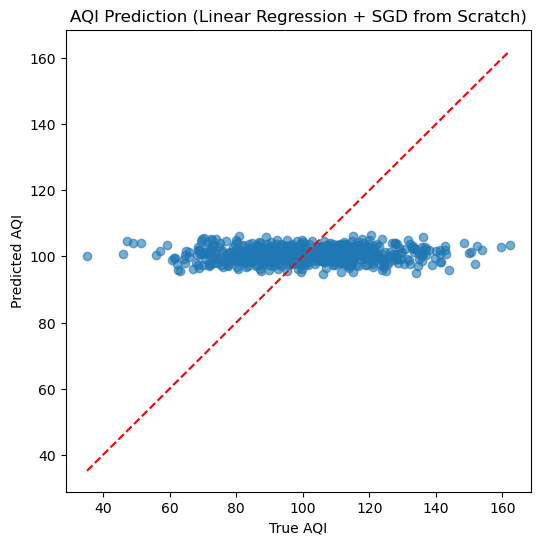

In [63]:
# True Vs Predicted Plot 

plt.figure(figsize=(6,6))
plt.scatter(y_test_real,y_pred_real, alpha = 0.6)
plt.plot([y_test_real.min(),y_test_real.max()],
         [y_test_real.min(),y_test_real.max()],
         'r--')
plt.xlabel("True AQI")
plt.ylabel("Predicted AQI")
plt.title("AQI Prediction (Linear Regression + SGD from Scratch)")
plt.show()